<a href="https://colab.research.google.com/github/hgoosen/flood-sat/blob/model_training/floodsat_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FloodSat Model Training
This notebook was written by Henri Goosen (hgoosen - goosenhenri@gmail.com) for the 2026 Hackster: "Innovate the Future" Arduino Uno Q Hackathon
## Dataset
The notebook uses the Sen1Floods11 Dataset, generated by Cloud to Street.

Source:
https://github.com/cloudtostreet/Sen1Floods11

Citation:
> Bonafilia, D., Tellman, B., Anderson, T., Issenberg, E. 2020. Sen1Floods11: a georeferenced dataset to train and test deep learning flood algorithms for Sentinel-1. The IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR) Workshops, 2020, pp. 210-211.

## Sources
In the development of this notebook, I used the following sources:

*   Sen1Floods11 Example Notebook
    * https://github.com/cloudtostreet/Sen1Floods11/blob/master/Train.ipynb
    * This guide details how to properly use the data provided in the dataset, Sen1Floods11, and gives example code for making a model.
    * I used this as a starting place for updating the training library to Tensorflow, in order to use it with Google's LiteRT library.
*   Chapter 4 of TinyML: "The 'Hello World' of TinyML:
Building and Training a Model"
    * Citation:
    > TinyML by Pete Warden
and Daniel Situnayake (O’Reilly). Copyright Pete Warden and Daniel Situnayake,
978-1-492-05204-3
* Google for Developers:
    * TensorFlow Model Conversion: https://developers.google.com/edge/litert/conversion/tensorflow/overview.md
    * Build LiteRT models: https://developers.google.com/edge/litert/conversion/tensorflow/build/overview
    * Using GPU w/ LiteRT: https://developers.google.com/edge/litert/performance/delegates
* Model
> Disclaimer: GenAI was used in this section to help select and build a complex model
    * MobileNetV2 Backbone
        * https://github.com/tensorflow/models/tree/master/research/slim/nets/mobilenet
    * DeepLabV3+ Network
        * https://github.com/tensorflow/models/blob/master/research/deeplab
    * Gemini Pro Conversation
        * https://share.gemini.google/jCkr9CNMJv1b
        * References in conversation are as follows:
            * Sen1Floods11 Example Notebook (cited above)
            * Google for Developers GPU w/ LiteRT (cited above)
            * Tensor Flow Model Garden (https://github.com/tensorflow/models/blob/master/official/vision/MODEL_GARDEN.md)
            * Arduino Uno Q datasheet (https://docs.arduino.cc/hardware/uno-q/)



# Dependencies

By the end of this section, the notebook will have all necessary libraries, a clean folder structure, and all the data imported with training labels

## Including Libaries

In [1]:
import os

# Google Cloud authorization for dataset
from google.colab import auth

# --- Model dependencies below ---

import tensorflow as tf
#   ML library for defining & training models

import numpy as np
#   Math library for representing tensors in arrays

import matplotlib.pyplot as plt
#   Library for plotting data

from PIL import Image
#   Image processing library for easier image transforms

import rasterio
#   Geospatial raster library that converts TIFF to numpy arrays and GeoJSON

import csv
#   Library for CSV file support

## Building Environment

In [2]:
# Add directory for model checkpoints
%cd /home
!sudo mkdir checkpoints

/home


In [3]:
# Adding directories for raw data
!sudo mkdir files
!sudo mkdir files/S1
!sudo mkdir files/Labels

## Downloading dataset

In [4]:
# Completing authorization for download
auth.authenticate_user()

!curl https://sdk.cloud.google.com | bash

Streaming output truncated to the last 5000 lines.
google-cloud-sdk/lib/surface/source/project_configs/update.py
google-cloud-sdk/lib/surface/source/project_configs/update.yaml
google-cloud-sdk/lib/surface/source/repos/__init__.py
google-cloud-sdk/lib/surface/source/repos/clone.py
google-cloud-sdk/lib/surface/source/repos/clone.yaml
google-cloud-sdk/lib/surface/source/repos/config/__init__.py
google-cloud-sdk/lib/surface/source/repos/config/export.yaml
google-cloud-sdk/lib/surface/source/repos/create.py
google-cloud-sdk/lib/surface/source/repos/create.yaml
google-cloud-sdk/lib/surface/source/repos/delete.py
google-cloud-sdk/lib/surface/source/repos/delete.yaml
google-cloud-sdk/lib/surface/source/repos/describe.py
google-cloud-sdk/lib/surface/source/repos/describe.yaml
google-cloud-sdk/lib/surface/source/repos/get_iam_policy.py
google-cloud-sdk/lib/surface/source/repos/get_iam_policy.yaml
google-cloud-sdk/lib/surface/source/repos/list.py
google-cloud-sdk/lib/surface/source/repos/list.ya

In [5]:
# Downloading train, test & validation splits for flood water
!gcloud storage cp gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv .
!gcloud storage cp gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_test_data.csv .
!gcloud storage cp gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv .

Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv to file://./flood_train_data.csv
Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_test_data.csv to file://./flood_test_data.csv
Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv to file://./flood_valid_data.csv


In [6]:
# Downloading raw train, test & validation data of hand-labeled flood images
!gcloud storage cp -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand files/S1
!gcloud storage cp -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand files/Labels

Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_103757_S1Hand.tif to file://files/S1/S1Hand/Bolivia_103757_S1Hand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_129334_S1Hand.tif to file://files/S1/S1Hand/Bolivia_129334_S1Hand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_195474_S1Hand.tif to file://files/S1/S1Hand/Bolivia_195474_S1Hand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_23014_S1Hand.tif to file://files/S1/S1Hand/Bolivia_23014_S1Hand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_233925_S1Hand.tif to file://files/S1/S1Hand/Bolivia_233925_S1Hand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_242570_S1Hand.tif to file://files/S1/S1Hand/Bolivia_242570_S1Hand.tif
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_290290_S1Hand.tif to file://files/S1/S1Hand/Bolivi

# Processing Data
By the end of this section, the data will be formatted correctly, ready for training and inference.

**Dataset:**
  > Sen1Floods11 (https://github.com/cloudtostreet/Sen1Floods11)

Dataset is build upon georeferenced Sentinel-1 Synthetic Aperture Radar (SAR) imagery. Note that there are two distinct channels: VV and VH. VV detects surface roughness and VH detects density of vegetation.

**Data input:**

Raw satellite data is ingested as two-channel raster. After processing, we will have an input tensor of `(256, 256, 2)`.

**Data labels:**

Corresponding labels are surface masks of flooded areas. A classification of '0' denotes dry or background, where '1' denotes flooding. '255' is assigned to unclassified pixels.

In [7]:
# --- GLOBAL CONSTANTS

BATCH_SIZE = 16
# Defines how many pieces of training data to feed network before measuring accuracy

NUM_CLASSES = 2
# Defines total number of distinct classification categories the model will predict (background / flood)

PIXEL_H = 256
PIXEL_W = PIXEL_H
# Defines size of the crops used in the training pipeline (256 x 256)

ORIGINAL_IMG_SIZE = 512
# Defines original height & width of TIFF images

DEPTH_CHANNELS = 2
# Defines the VV and VH SAR bands on the Sentinel-1

OLD_IGNORE_CLASS = -1
IGNORE_CLASS = 255
# Defines the invalid pixels that loss functions should ignore

In [8]:
# --- PROCESSING CONSTANTS

CLIP_MIN = -50.0
# Defines the lower bound for clipping the raw SAR backscatter values to remove extreme outliers

CLIP_MAX = 1.0
# Defines the upper bound for clipping the raw SAR backscatter values

NORM_OFFSET = 50.0
# Defines the value added to shift the clipped range so it begins at zero

NORM_DIVISOR = 51.0
# Defines the denominator used to scale the shifted values to a standard 0.0 - 1.0 float range

SHUFFLE_BUFFER = 100
# Defines the maximum number of elements held in memory from which the training dataset will randomly sample

In [9]:
""" Extracts image paths from dataset split CSVs. """
def parse_csv(filepath, input_path, label_path):
  image_paths, mask_paths = [], []
  with open(filepath, 'r') as csv_file:
    for line in csv.reader(csv_file):
      image_paths.append(os.path.join(input_path, line[0]))
      mask_paths.append(os.path.join(label_path, line[1]))
  return image_paths, mask_paths

In [10]:
""" Reads and normalizes the TIFF files. """
def process_tiff_files(img_path, mask_path):
  img_path_str = img_path.decode('utf-8')
  mask_path_str = mask_path.decode('utf-8')

  with rasterio.open(img_path_str) as src:
    image_array = src.read() # (DEPTH_CHANNELS, ORIGINAL_IMAGE_SIZE, ORIGINAL_IMAGE_SIZE)

  with rasterio.open(mask_path_str) as src:
    mask_array = src.read(1) # (ORIGINAL_IMG_SIZE, ORIGINAL_IMG_SIZE)

  # Normalizing
  image_array = np.nan_to_num(image_array)
  image_array = np.clip(image_array, CLIP_MIN, CLIP_MAX)
  image_array = (image_array - NORM_OFFSET) / NORM_DIVISOR

  # Convert ignore class
  mask_array[mask_array == OLD_IGNORE_CLASS] = IGNORE_CLASS

  # Move channels to end
  image_array = np.moveaxis(image_array, 0, -1).astype(np.float32)
  mask_array = mask_array.astype(np.int32)

  return image_array, mask_array

In [11]:
""" Converts processing function into TensorFlow operation. """
def tf_parse(img_path, mask_path):
  image, mask = tf.numpy_function(
      func = process_tiff_files,
      inp = [img_path, mask_path],
      Tout = [tf.float32, tf.int32]
  )

  # Statically define shapes for Adreno GPU requirements
  image.set_shape([ORIGINAL_IMG_SIZE, ORIGINAL_IMG_SIZE, DEPTH_CHANNELS])
  mask.set_shape([ORIGINAL_IMG_SIZE, ORIGINAL_IMG_SIZE])

  mask_float = tf.cast(mask, tf.float32)

  # Crop to target size for training
  stacked = tf.concat([image, tf.expand_dims(mask_float, axis=-1)], axis=-1)
  stacked_channels = DEPTH_CHANNELS + 1
  cropped = tf.image.random_crop(stacked, size=[PIXEL_H, PIXEL_W, stacked_channels])

  img_cropped = cropped[:, :, :DEPTH_CHANNELS]
  mask_cropped = tf.cast(cropped[:, :, DEPTH_CHANNELS], tf.int32)

  return img_cropped, mask_cropped

In [12]:
def build_dataset(csv_file, input_path='files/S1/S1Hand', label_path='files/Labels/LabelHand', batch_size=BATCH_SIZE, is_training=True):
  img_paths, mask_paths = parse_csv(csv_file, input_path, label_path)

  dataset = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
  if is_training:
    dataset = dataset.shuffle(buffer_size=SHUFFLE_BUFFER)

  dataset = dataset.map(tf_parse, num_parallel_calls=tf.data.AUTOTUNE)

  dataset = dataset.cache()

  dataset = dataset.batch(BATCH_SIZE)
  dataset = dataset.prefetch(tf.data.AUTOTUNE)

  return dataset

In [13]:
train_dataset = build_dataset('flood_train_data.csv', batch_size=BATCH_SIZE, is_training=True)
valid_dataset = build_dataset('flood_valid_data.csv', batch_size=BATCH_SIZE, is_training=False)

# Model Definition
By the end of this section, the model will be defined & compiled, ready for training.

In [14]:
# I decided to use the MobileNetV2 Architecture for compatability with LiteRT GPU delegates
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

In [60]:
# DISCLAIMER: The following function is derived from a GenAI implementation using verified sources.
#             I, Henri Goosen (hgoosen), take responsibility of this adaptation and have adjusted it to
#             fit my standards of readability and correctness. (see citations in Sources)

def build_deeplabv3_unoq(
    input_shape=(PIXEL_H, PIXEL_W, DEPTH_CHANNELS),
    num_classes=NUM_CLASSES):

  # --- CONSTANTS

  ASPP_CHANNELS = 256
  # Defines the number of filters used in ASPP (how much contextual info)

  DILATION_RATE_1 = 6
  DILATION_RATE_2 = 12
  DILATION_RATE_3 = 18
  # Defines the spacing between kernel values in dilated convolutions (multi-scale context)

  LOW_LEVEL_CHANNELS = 48
  # Defines the number of filters used to compress low-level features from backbone (prevents overpowering)

  ASPP_UPSAMPLE_FACTOR = (8, 8)
  # Defines scaling factor to expand 1x1 GAP tensor to 8x8

  DECODER_UPSAMPLE_FACTOR = (8, 8)
  # Defines scaling factor to align high-level ASPP maps (8x8) with low-level maps (64x64)

  FINAL_UPSAMPLE_FACTOR = (4, 4)
  # Defines the scaling factor to expand the final decoder output (64x64) back to original (256x256)

  # --- MODEL CONSTRUCTION

  sat_photo = layers.Input(shape=input_shape, name="sat_photo")

  padding_layer = layers.Lambda(
      lambda x: tf.zeros_like(x[:, :, :, :1]),
      output_shape=(PIXEL_H, PIXEL_W, 1),
      name="padding"
  )

  # Zero tensor for padding 2-channel input into 3 channels for MobileNetV2
  padding = padding_layer(sat_photo)

  concat_input_layer = layers.Concatenate(axis=-1, name="rgb_equivalent")
  three_channel = concat_input_layer([sat_photo, padding])

  mobilenet = MobileNetV2(
      input_tensor=three_channel,
      weights='imagenet',
      include_top=False,
      alpha=1.0
  )

  high_level = mobilenet.output
  low_level = mobilenet.get_layer('block_2_expand_relu').output

  # --- Atrous Spatial Pyramid Pooling (ASPP)

  # 1.) 1 x 1 Convolution
  conv_1x1_layer = layers.Conv2D(
      filters=ASPP_CHANNELS,
      kernel_size=(1, 1),
      padding='same',
      use_bias=False
  )
  conv_1x1 = conv_1x1_layer(high_level)
  conv_1x1 = layers.BatchNormalization()(conv_1x1)
  conv_1x1 = layers.ReLU()(conv_1x1)

  # 2.) Dilated Convolution (Rates 2 - 18)
  dilated_rate6_layer = layers.Conv2D(
      filters=ASPP_CHANNELS,
      kernel_size=(3, 3),
      dilation_rate=DILATION_RATE_1,
      padding='same',
      use_bias=False
  )
  dilated_rate6 = dilated_rate6_layer(high_level)
  dilated_rate6 = layers.BatchNormalization()(dilated_rate6)
  dilated_rate6 = layers.ReLU()(dilated_rate6)

  dilated_rate12_layer = layers.Conv2D(
      filters=ASPP_CHANNELS,
      kernel_size=(3, 3),
      dilation_rate=DILATION_RATE_2,
      padding='same',
      use_bias=False
  )
  dilated_rate12 = dilated_rate12_layer(high_level)
  dilated_rate12 = layers.BatchNormalization()(dilated_rate12)
  dilated_rate12 = layers.ReLU()(dilated_rate12)

  dilated_rate18_layer = layers.Conv2D(
      filters=ASPP_CHANNELS,
      kernel_size=(3, 3),
      dilation_rate=DILATION_RATE_3,
      padding='same',
      use_bias=False
  )
  dilated_rate18 = dilated_rate18_layer(high_level)
  dilated_rate18 = layers.BatchNormalization()(dilated_rate18)
  dilated_rate18 = layers.ReLU()(dilated_rate18)

  # 3.) Image Pooling Branch
  gap = layers.GlobalAveragePooling2D()(high_level)

  reshape_layer = layers.Reshape((1, 1, gap.shape[-1]))
  reshaped = reshape_layer(gap)

  conv_pool_layer = layers.Conv2D(
      filters=ASPP_CHANNELS,
      kernel_size=(1, 1),
      padding='same',
      use_bias=False
  )
  conv_pool = conv_pool_layer(reshaped)
  bn_pool = layers.BatchNormalization()(conv_pool)
  relu_pool = layers.ReLU()(bn_pool)

  upsample_pool_layer = layers.UpSampling2D(
      size=ASPP_UPSAMPLE_FACTOR,
      interpolation='bilinear'
  )
  upsampled_pool = upsample_pool_layer(relu_pool)

  # 4.) Concatenate & Project

  concat_aspp_layer = layers.Concatenate(axis=-1)
  concatenated_features = concat_aspp_layer([
      conv_1x1,
      dilated_rate6,
      dilated_rate12,
      dilated_rate18,
      upsampled_pool
  ])

  project_aspp_layer = layers.Conv2D(
      filters=ASPP_CHANNELS,
      kernel_size=(1, 1),
      padding='same',
      use_bias=False
  )
  projected = project_aspp_layer(concatenated_features)
  projected = layers.BatchNormalization()(projected)
  projected = layers.ReLU()(projected)

  # --- DECODER STAGE

  upsample_high_layer = layers.UpSampling2D(
      size=DECODER_UPSAMPLE_FACTOR,
      interpolation='bilinear'
  )
  upsampled_high = upsample_high_layer(projected)

  project_low_layer = layers.Conv2D(
      filters=LOW_LEVEL_CHANNELS,
      kernel_size=(1, 1),
      padding='same',
      use_bias=False
  )
  projected_low = project_low_layer(low_level)
  projected_low = layers.BatchNormalization()(projected_low)
  projected_low = layers.ReLU()(projected_low)

  concat_decoder_layer = layers.Concatenate(axis=-1)
  concatenated = concat_decoder_layer([upsampled_high, projected_low])

  conv_first_layer = layers.Conv2D(
      filters=ASPP_CHANNELS,
      kernel_size=(3, 3),
      padding='same',
      use_bias=False
  )
  conv_first = conv_first_layer(concatenated)
  conv_first = layers.BatchNormalization()(conv_first)
  conv_first = layers.ReLU()(conv_first)

  conv_second_layer = layers.Conv2D(
      filters=ASPP_CHANNELS,
      kernel_size=(3, 3),
      padding='same',
      use_bias=False
  )
  conv_second = conv_second_layer(conv_first)
  conv_second = layers.BatchNormalization()(conv_second)
  conv_second = layers.ReLU()(conv_second)

  # --- FINAL UPSAMPLE & CLASSIFIER

  final_upsample_layer = layers.UpSampling2D(
      size=FINAL_UPSAMPLE_FACTOR,
      interpolation='bilinear'
  )
  final_upsampled = final_upsample_layer(conv_second)

  logits_layer = layers.Conv2D(
      filters=num_classes,
      kernel_size=(1, 1),
      activation='linear'
  )
  logits = logits_layer(final_upsampled)

  return Model(sat_photo, logits, name="FloodSat_DeepLabV3_UnoQ")

In [16]:
model = build_deeplabv3_unoq()
model.summary()

/tmp/ipykernel_7209/512443740.py:46: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "FloodSat_DeepLabV3_UnoQ"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sat_photo           │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ padding (Lambda)    │ (None, 256, 256,  │          0 │ sat_photo[0][0]   │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_equivalent      │ (None, 256, 256,  │          0 │ sat_photo[0][0],  │
│ (Concatenate)       │ 3)                │            │ padding[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ rgb_equivalent[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis

 Total params: 13,394,434 (51.10 MB)

 Trainable params: 13,356,130 (50.95 MB)

 Non-trainable params: 38,304 (149.62 KB)

Compilation

In [17]:
LEARNING_RATE = 5e-4
# Defines the step at each iteration, moving toward minimum of loss function

In [18]:
""" Custom Sparse Mean IoU metric. """
class SparseMeanIoU(tf.keras.metrics.MeanIoU):
  def update_state(self, y_true, y_pred, sample_weight=None):
    y_pred_classes = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)

    if (len(y_true.shape) == 4):
      y_true_squeezed = tf.squeeze(y_true, axis=-1)
    else:
       y_true_squeezed = y_true

    y_true_cast = tf.cast(y_true_squeezed, tf.int32)

    ignore_mask = tf.cast(tf.not_equal(y_true_cast, IGNORE_CLASS), tf.int32)

    if sample_weight is None:
      sample_weight = ignore_mask
    else:
      sample_weight = tf.cast(sample_weight, tf.int32) * ignore_mask

    y_true_safe = tf.where(tf.equal(y_true_cast, IGNORE_CLASS), tf.zeros_like(y_true_cast), y_true_cast)

    return super().update_state(y_true_safe, y_pred_classes, sample_weight)

In [19]:
# Optimizer - Uses Adam to dynamically adjust parameter learning rates for MobileNetV2

adam_optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# Loss Function - Uses Categorical Crossentropy to penalize the model for confident errors

segmentation_loss = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True,
    ignore_class=IGNORE_CLASS
)

# Metric - IoU measures the percentage of overlap between predicted & actual flood zones

iou_metric = SparseMeanIoU(
    num_classes=NUM_CLASSES,
    name='iou'
)

In [20]:
model.compile(
    optimizer=adam_optimizer,
    loss=segmentation_loss,
    metrics=[iou_metric]
)

# Training
By the end of this section, the model will be trained and ready for inference.

## Running Training

In [45]:
EPOCHS = 200
# Defines how many times the entire training set will be run through the network

In [46]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='/home/checkpoints/best_floodsat_model.keras',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

In [47]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_iou',
    mode='max',
    patience=40,
    restore_best_weights=True
)

In [48]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=20,
    min_lr=1e-6
)

In [49]:
callbacks_list = [checkpoint_callback, early_stopping, reduce_lr]

In [50]:
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=valid_dataset,
    callbacks=callbacks_list
)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - iou: 0.8408 - loss: 0.0911
Epoch 1: val_loss improved from None to 0.34184, saving model to /home/checkpoints/best_floodsat_model.keras

Epoch 1: finished saving model to /home/checkpoints/best_floodsat_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 316ms/step - iou: 0.8523 - loss: 0.0781 - val_iou: 0.6181 - val_loss: 0.3418 - learning_rate: 2.5000e-04
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - iou: 0.8517 - loss: 0.0793
Epoch 2: val_loss improved from 0.34184 to 0.25588, saving model to /home/checkpoints/best_floodsat_model.keras

Epoch 2: finished saving model to /home/checkpoints/best_floodsat_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 301ms/step - iou: 0.8608 - loss: 0.0707 - val_iou: 0.5267 - val_loss: 0.2559 - learning_rate: 2.5000e-04
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - iou: 0.8593 - loss: 0.0752
Epoch 3: val_loss did not improve from 0.25588
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - iou: 0.8623 - l

## Graphing Performance

In [51]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

Training & Validation Loss

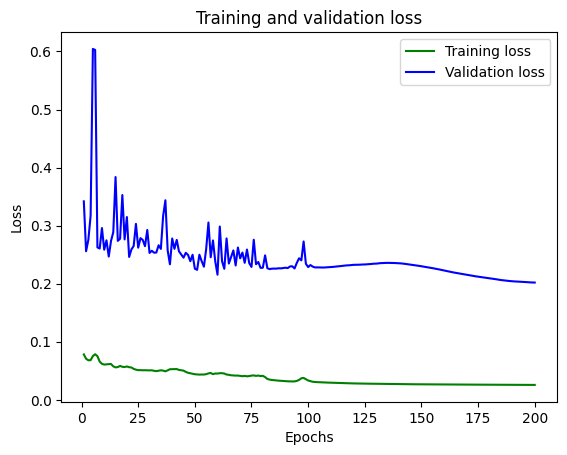

In [52]:
plt.plot(epochs, loss, 'g', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Intersection over Union (IoU)

In [53]:
iou = history.history['iou']
val_iou = history.history['val_iou']

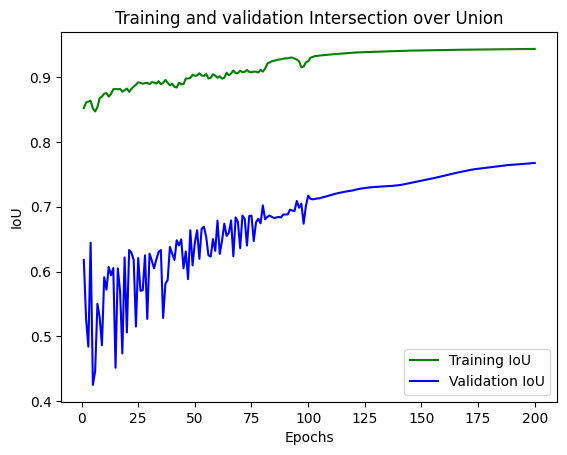

In [54]:
plt.plot(epochs, iou, 'g', label='Training IoU')
plt.plot(epochs, val_iou, 'b', label='Validation IoU')
plt.title('Training and validation Intersection over Union')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.legend()
plt.show()

Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


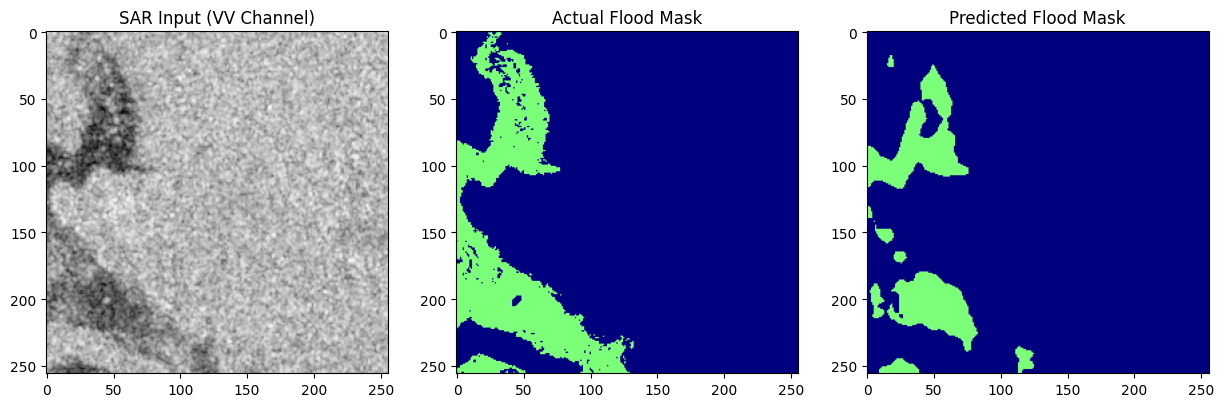

In [55]:
index = 8

for images, masks in valid_dataset.take(1):
  predictions = model.predict(images)

  predicted_masks = tf.argmax(predictions, axis=-1)

  plt.figure(figsize=(15, 5))

  plt.subplot(1, 3, 1)
  plt.title('SAR Input (VV Channel)')
  plt.imshow(images[index, :, :, 0], cmap='gray')

  plt.subplot(1, 3, 2)
  plt.title('Actual Flood Mask')
  plt.imshow(masks[index], cmap='jet', vmin=0, vmax=2)

  plt.subplot(1, 3, 3)
  plt.title('Predicted Flood Mask')
  plt.imshow(predicted_masks[index], cmap='jet', vmin=0, vmax=2)

  plt.show()
  break

In [56]:
model.save('/home/checkpoints/final_floodsat_model.keras')

# Optimizing for Arduino Uno Q

In [ ]:
best_model = tf.keras.models.load_model(
    '/home/checkpoints/best_floodsat_model.keras',
    custom_objects={
        'SparseMeanIoU': SparseMeanIoU,
    },
    safe_mode=False
)

In [64]:
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

In [65]:
def generate_representative_data():
  for img_batch, _ in train_dataset.take(50):
    yield[tf.cast(img_batch, tf.float32)]

converter.representative_dataset = generate_representative_data

In [66]:
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

In [67]:
tflite_model = converter.convert()

tflite_path = '/home/checkpoints/floodsat_model_adreno.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpb7fr22s9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 2), dtype=tf.float32, name='sat_photo')
Output Type:
  TensorSpec(shape=(None, 256, 256, 2), dtype=tf.float32, name=None)
Captures:
  139168095702288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168131947536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168129221072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168131947920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168131947152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168129221456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168129223760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168129223568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168129223184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139168129221264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1391681

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


## Comparing Outputs (LiteRT vs. TensorFlow)

In [80]:
import time
# Using to check inference time

In [81]:
for img_batch, mask_batch in valid_dataset.take(1):
    sample_images = img_batch.numpy()
    sample_masks = mask_batch.numpy()
    break

In [84]:
image_index = 8

test_image = sample_images[image_index : image_index + 1] # Shape: (1, 256, 256, 2)
test_mask = sample_masks[image_index]

In [85]:
start_time = time.time()
keras_preds = model.predict(test_image)
keras_time = (time.time() - start_time) * 1000.0 # Convert to ms
keras_mask_class = np.argmax(keras_preds[0], axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


In [86]:
tflite_path = '/home/checkpoints/floodsat_model_adreno.tflite'
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [87]:
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

interpreter.set_tensor(input_details[0]['index'], test_image.astype(np.float32))

In [88]:
start_time = time.time()
interpreter.invoke()
tflite_time = (time.time() - start_time) * 1000.0 # Convert to ms

In [89]:
tflite_preds = interpreter.get_tensor(output_details[0]['index'])
tflite_mask_class = np.argmax(tflite_preds[0], axis=-1)

In [90]:
print(f"Keras Inference Time: {keras_time:.2f} ms")
print(f"LiteRT Inference Time: {tflite_time:.2f} ms")

Keras Inference Time: 92.20 ms
LiteRT Inference Time: 131.03 ms


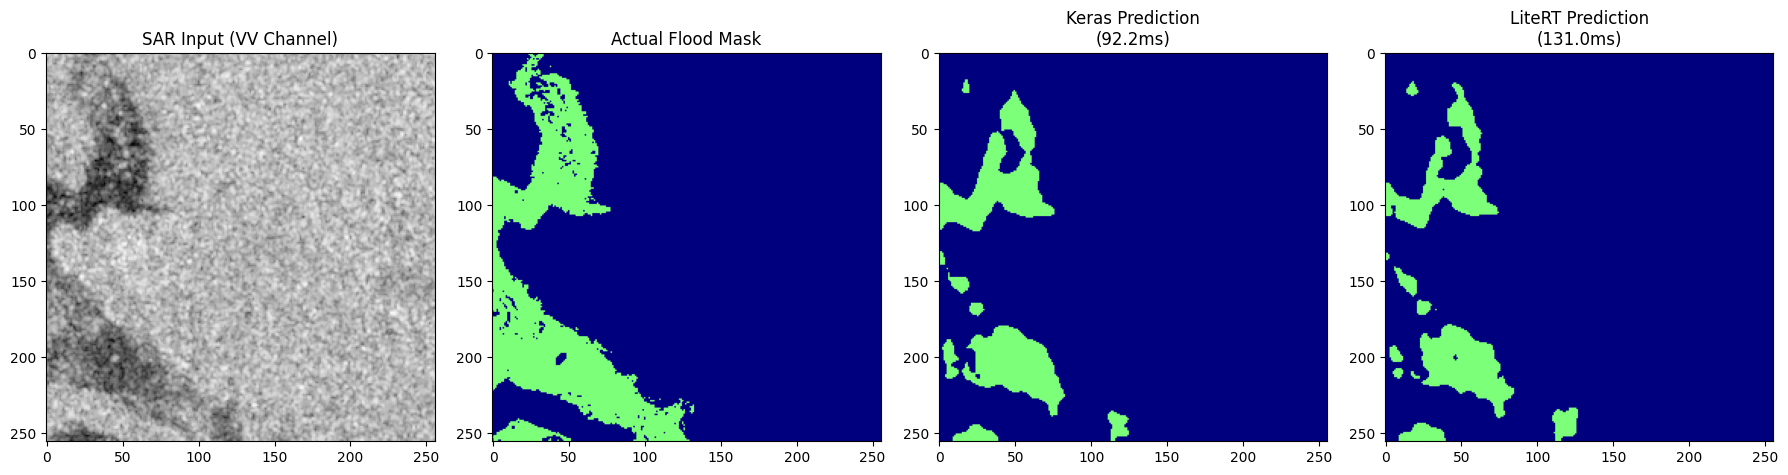

In [91]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.title('SAR Input (VV Channel)')
plt.imshow(test_image[0, :, :, 0], cmap='gray')

plt.subplot(1, 4, 2)
plt.title('Actual Flood Mask')
plt.imshow(test_mask, cmap='jet', vmin=0, vmax=2)

plt.subplot(1, 4, 3)
plt.title(f'Keras Prediction\n({keras_time:.1f}ms)')
plt.imshow(keras_mask_class, cmap='jet', vmin=0, vmax=2)

plt.subplot(1, 4, 4)
plt.title(f'LiteRT Prediction\n({tflite_time:.1f}ms)')
plt.imshow(tflite_mask_class, cmap='jet', vmin=0, vmax=2)

plt.tight_layout()
plt.show()

# Final Results:

Original Model:

*   Inference time: 92.2ms
*   Size: 154 MB

LiteRT Model:

* Inference time: 131.0 ms
* Size: 13.3 MB

(see above for accuracy)


Performance:

LiteRT: 11x smaller, 29.6% slower inference